In [69]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr, scipy.io as sio

%matplotlib inline
import matplotlib.pyplot as plt, matplotlib.path as mpath
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs, cartopy.feature as cfeature
plt.rcParams['figure.dpi'] = 110

DATA = Path('/Users/advik/Library/Mobile Documents/com~apple~CloudDocs/Documents/'
            'Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium')

N_POTENTIAL, N_EXIST = 5794, 118      # rows 0..5793 potential; 5794..5911 existing
N_SITES = N_POTENTIAL + N_EXIST       # 5912

ENSEMBLE = 'MME'      # 'MME' (1001 members) | 'MRE' (160)
VARIABLE = 'Temp'     # 'Temp' | 'Accum'

# R derivation. RSheet.csv (== AccumR.mat 'SafeR') is the "accumR" variant and
# reproduces all four BS_* outputs exactly, for BOTH temperature and
# accumulation. "orogR" is the alternative derivation.
#   NOTE: temp*_RComb.csv / temp*_ROrog.csv are RESULT files, not R inputs.
R_MODE = 'accumR'          # 'accumR' | 'orogR'


print('data dir exists:', DATA.exists())


data dir exists: True


In [70]:
def read_numbers(path):
    """Whitespace/newline-delimited numeric file, skipping header tokens."""
    out = []
    for tok in Path(path).read_text().split():
        try: out.append(float(tok))
        except ValueError: pass
    return np.asarray(out, float)

def load_Ye(variable=VARIABLE, ensemble=ENSEMBLE):
    key = f'{variable}{ensemble}Ye'
    Ye = np.asarray(sio.loadmat(DATA / f'{key}.mat')[key], float)
    assert Ye.shape[0] == N_SITES, Ye.shape
    return Ye

def load_metric(variable=VARIABLE, ensemble=ENSEMBLE):
    """The climate metric J -- one value per ensemble member.
    MMETemp.mat / MRETemp.mat / MMEAccum.mat / MREAccum.mat, each (1 x nMembers)."""
    key = f'{ensemble}{variable}'
    return np.asarray(sio.loadmat(DATA / f'{key}.mat')[key], float).ravel()

def load_R(mode=R_MODE, clip_negative=True):
    """Observation error variances, one per site (5912).

    'accumR' -> RSheet.csv, identical to AccumR.mat['SafeR']. Validated: gives
                corr 1.000000 / ratio 1.0000 against all four BS_* outputs.
    'orogR'  -> orographyR.csv (5794 potential) + orographyRExist.csv (118).
    """
    if mode == 'accumR':
        R = read_numbers(DATA / 'RSheet.csv')
    elif mode == 'orogR':
        R = np.concatenate([read_numbers(DATA / 'orographyR.csv')[:N_POTENTIAL],
                            read_numbers(DATA / 'orographyRExist.csv')[:N_EXIST]])
    else:
        raise ValueError(mode)

    if clip_negative and (R < 0).any():
        print(f'  clipped {(R < 0).sum()} negative R values to 0')
        R = np.clip(R, 0, None)
    assert R.size == N_SITES, R.size
    return R

Ye, J, R = load_Ye(), load_metric(), load_R()
assert J.size == Ye.shape[1], (J.size, Ye.shape[1])
print(f'Ye {Ye.shape}   J {J.shape}   R {R.shape}   (mode={R_MODE})')


nM = Ye.shape[1]; unbias = 1.0 / (nM - 1)
Yvar_all = unbias * ((Ye - Ye.mean(1, keepdims=True)) ** 2).sum(1)
ratio = np.median(R[:N_POTENTIAL]) / np.median(Yvar_all[:N_POTENTIAL])
print(f'Ye {Ye.shape}   J {J.shape}   R {R.shape}   ({R_FILE[(VARIABLE,ENSEMBLE)]})')
print(f'median Ye variance {np.median(Yvar_all):.4g}   median R {np.median(R):.4g}   '
      f'ratio {ratio:.2f}')
if ratio > 5:
    print(f'  WARNING: R is {ratio:.0f}x the Ye variance -- it will dominate the '
          f'denominator and flatten the result. Check R_FILE.')


Ye (5912, 1001)   J (1001,)   R (5912,)   (mode=accumR)
Ye (5912, 1001)   J (1001,)   R (5912,)   (tempMME_RComb.csv)
median Ye variance 1.065   median R 123.6   ratio 117.43


In [71]:
# Reproduce the MATLAB blank-slate output exactly.
tgt = read_numbers(DATA / f'BS_{ENSEMBLE}_{VARIABLE.lower()}_accumR.csv')
dv  = OptimalSensor(J, Ye[:N_POTENTIAL], load_R('accumR')[:N_POTENTIAL]).evaluate()
print(f'corr  {np.corrcoef(dv, tgt)[0,1]:.8f}   ratio {dv.max()/tgt.max():.6f}')
assert abs(np.corrcoef(dv, tgt)[0,1] - 1) < 1e-9, 'does not match MATLAB'
print('matches the MATLAB output exactly')


corr  1.00000000   ratio 0.999967
matches the MATLAB output exactly


In [72]:
# CCSM4 (CAM4 finite-volume) grid, generated analytically -- identical to
# reading `lat`/`lon` from the 2.6 GB pr_sfc_Amon_CCSM4 file, but instant.
ccsm_lat = np.linspace(-90, 90, 192)
ccsm_lon = np.arange(288) * 1.25

def build_site_coords():
    """Reproduce FindGridSites.ipynb: first 32 latitude rows, masked to land
    by a regridded ERA5 t2m field (data.nc, 2 MB)."""
    era = xr.open_dataset(DATA / 'data.nc')
    t2m = era[list(era.data_vars)[0]].values
    tempMask = np.roll(t2m, 1800, axis=2)
    latInd = pd.read_csv(DATA / 'latInd.csv').values.ravel().astype(int)

    tempRegrid = np.zeros((32, 3600))
    for i, item in enumerate(latInd):
        tempRegrid[i, :] = tempMask[0, item]
    second = np.zeros((32, 7200))
    for i in range(32):
        second[i, :7198] = np.dstack(
            (tempRegrid[i, :-1],
             tempRegrid[i, :-1] + np.diff(tempRegrid[i]) / 2.0)).ravel()
    regrid = second[:, ::25]

    la, lo = [], []
    for i in range(32):
        for j in range(288):
            if regrid[i, j] > 0:
                la.append(ccsm_lat[i]); lo.append(ccsm_lon[j])
    return np.array(la), np.array(lo)

site_lat, site_lon = build_site_coords()
assert site_lat.size == N_POTENTIAL, site_lat.size
print(f'{site_lat.size} potential sites  (lat {site_lat.min():.1f} to {site_lat.max():.1f})')


5794 potential sites  (lat -90.0 to -62.7)


In [73]:
def variance_reduction(Jdev, Ydev, Rvar, unbias):
    """DASH varianceReduction.m:
         deltaVar = (unbias * (Ydev * Jdev')).^2 ./ (Yvar + Rvar)
    Metric variance constrained by each site ASSIMILATED ALONE."""
    Yvar = unbias * (Ydev ** 2).sum(1)
    return (unbias * (Ydev @ Jdev)) ** 2 / (Yvar + Rvar)

def adjusted_gain(Knum, Kdenom, Rbest):
    """dash.kalman.adjusted, scalar case: Knum * Ksqrt^-1 * (Ksqrt + sqrt(R))^-1"""
    ks = np.sqrt(Kdenom)
    return Knum / ks / (ks + np.sqrt(Rbest))

class OptimalSensor:
    """Port of DASH @optimalSensor (Comboul et al. 2015).

    Needs no observations -- only the metric J, estimates Ye and error
    variances R.

    `dash_estimate_update`: DASH updates Ydev with the SCALAR gain derived from
    Jdev, broadcast across sites, rather than each site's own
    cov(Ydev_i, Ybest). Both your local run.m and the official GitHub version
    do this, so it is the default. Set False for the per-site gain.
    """
    def __init__(self, J, Ye, R, dash_estimate_update=True):
        J = np.asarray(J, float).ravel()
        self.nM = J.size
        self.unbias = 1.0 / (self.nM - 1)
        self.Jmean, self.Jdev = J.mean(), J - J.mean()
        self.Ydev = np.asarray(Ye, float) - np.asarray(Ye, float).mean(1, keepdims=True)
        self.R = np.asarray(R, float).ravel()
        self.dash_estimate_update = dash_estimate_update
        self.J0var = self.metric_variance()

    def metric_variance(self):
        return self.unbias * (self.Jdev ** 2).sum()

    def evaluate(self):
        return variance_reduction(self.Jdev, self.Ydev, self.R, self.unbias)

    def assimilate(self, idx):
        Ybest = self.Ydev[idx].copy(); Rbest = self.R[idx]
        Yvar = self.unbias * (Ybest ** 2).sum()
        Ka = adjusted_gain(self.unbias * (self.Jdev @ Ybest), Yvar + Rbest, Rbest)
        self.Jdev = self.Jdev - Ka * Ybest
        if self.dash_estimate_update:
            self.Ydev = self.Ydev - Ka * Ybest
        else:
            KaY = adjusted_gain(self.unbias * (self.Ydev @ Ybest), Yvar + Rbest, Rbest)
            self.Ydev = self.Ydev - KaY[:, None] * Ybest
        self.Ydev[idx] = np.nan
        return self.metric_variance()

    def run(self, N, exclude=None, verbose=True):
        """Rank -> select best -> update -> remove -> repeat.
        `exclude`: boolean mask of sites never selectable (e.g. ice shelves)."""
        sites, variances = [], []
        for s in range(N):
            dv = self.evaluate()
            dv = np.where(np.isfinite(dv), dv, -np.inf)
            if exclude is not None:
                dv = np.where(exclude, -np.inf, dv)
            for k in sites:
                dv[k] = -np.inf
            best = int(np.argmax(dv))
            v = self.assimilate(best)
            sites.append(best); variances.append(v)
            if verbose:
                print(f'  {s+1:3d}  site {best:5d} '
                      f'({site_lat[best]:7.2f}, {site_lon[best]:7.2f})  '
                      f'var {v:.6g}   cumulative {100*(1-v/self.J0var):5.1f}%')
        return np.array(sites), np.array(variances)

print('OptimalSensor defined')


OptimalSensor defined


In [64]:
from scipy.interpolate import griddata
from scipy.spatial import cKDTree

# Existing proxy sites. PlotVariances.ipynb patches one bad longitude.
_sites = pd.read_csv(DATA / 'Sites.csv', header=None).values.astype(float)
_sites[_sites[:, 1] == 161.64, 1] = -161.64
exist_lat, exist_lon = _sites[:, 0], _sites[:, 1]

def interp_field(values, ngrid=100, distance_threshold=1.0):
    """Interpolate site values onto a regular lon/lat mesh, as PlotVariances does.
    Cells further than `distance_threshold` (lon/lat units) from any site are
    blanked so the field doesn't extrapolate off the ice sheet."""
    v = np.asarray(values, float)
    lon_grid = np.linspace(site_lon.min(), site_lon.max(), ngrid)
    lat_grid = np.linspace(site_lat.min(), site_lat.max(), ngrid)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

    tree = cKDTree(np.column_stack((site_lon, site_lat)))
    d, _ = tree.query(np.column_stack((lon_mesh.ravel(), lat_mesh.ravel())))
    far = d.reshape(lon_mesh.shape) > distance_threshold

    grid = griddata((site_lon, site_lat), v, (lon_mesh, lat_mesh), method='linear')
    grid[far] = np.nan
    return lon_mesh, lat_mesh, grid

def plot_variance_map(values, title=None, top_idx=None, top_size=220,
                      cmap=plt.cm.Greens, vmin=0.0, vmax=1.0, figsize=(11, 11),
                      show_exist=True, cbar_label='constrained variance (normalised)'):
    """Interpolated field + blue existing proxies + optional ranked top-N circles."""
    lon_mesh, lat_mesh, grid = interp_field(values)

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.gridlines()

    pm = ax.pcolormesh(lon_mesh, lat_mesh, grid, zorder=0,
                       transform=ccrs.PlateCarree(), cmap=cmap,
                       vmin=vmin, vmax=vmax)
    if show_exist:
        ax.scatter(exist_lon, exist_lat, c='blue', s=50, linewidth=3, alpha=0.25,
                   zorder=1, transform=ccrs.PlateCarree())
    ax.coastlines()


total metric variance 0.619854
best site 4446 (-75.86, 340.00)
  absolute 0.0105097 = 1.7% of total metric variance


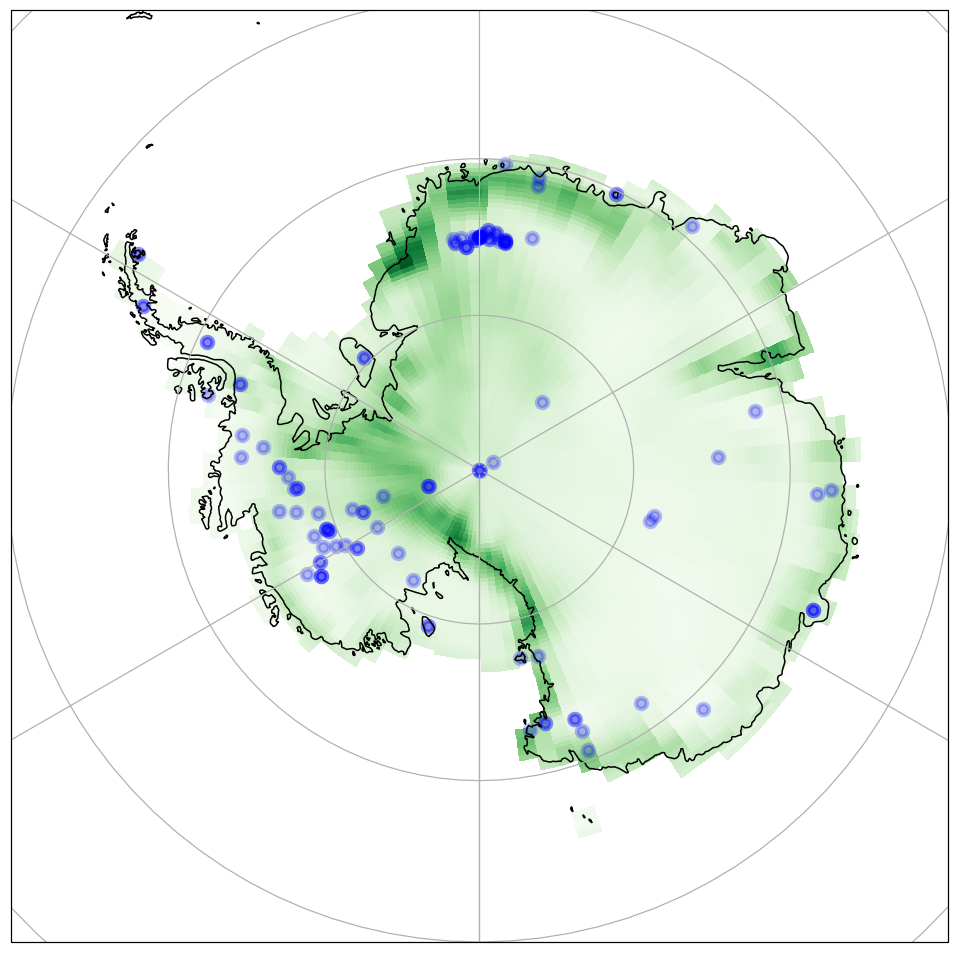

In [74]:
os_blank = OptimalSensor(J, Ye[:N_POTENTIAL], R[:N_POTENTIAL])
dv_blank = os_blank.evaluate()

blank_max = dv_blank.max()
frac_blank = dv_blank / blank_max          # self-normalised, 1.0 = best site

plot_variance_map(frac_blank, title=f'Blank slate — {VARIABLE} {ENSEMBLE}')

k = int(np.argmax(dv_blank))
print(f'total metric variance {os_blank.J0var:.6g}')
print(f'best site {k} ({site_lat[k]:.2f}, {site_lon[k]:.2f})')
print(f'  absolute {dv_blank[k]:.6g} = {100*dv_blank[k]/os_blank.J0var:.1f}% '
      f'of total metric variance')


variance before existing network : 0.619854
variance after  existing network : 0.48003
existing 118 proxies constrain   : 22.6%
best site 1598 (-85.29, 197.50)
  = 1.1% of the variance remaining after the existing network
  augmented best / blank-slate best = 0.515


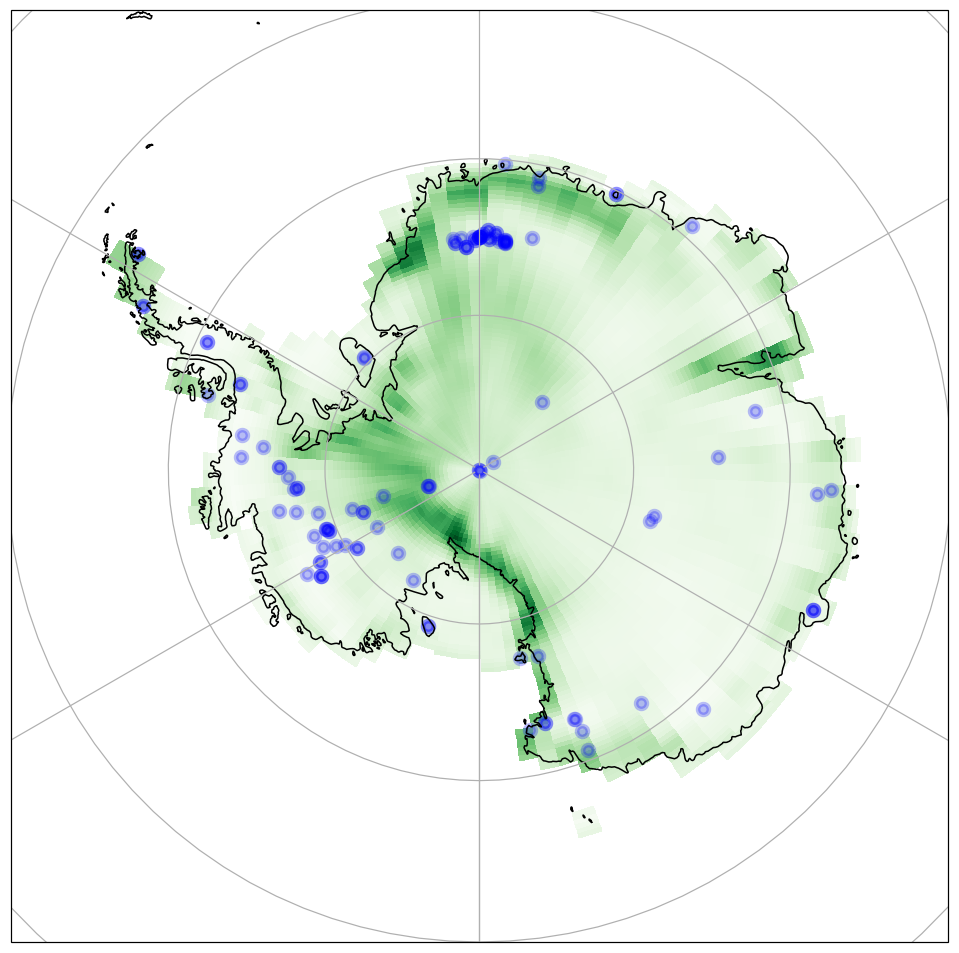

In [75]:
os_aug = OptimalSensor(J, Ye, R)
for idx in range(N_SITES - 1, N_POTENTIAL - 1, -1):    # 5911..5794, as in run.m
    os_aug.assimilate(idx)

v_exist = os_aug.metric_variance()
print(f'variance before existing network : {os_aug.J0var:.6g}')
print(f'variance after  existing network : {v_exist:.6g}')
print(f'existing 118 proxies constrain   : {100*(1-v_exist/os_aug.J0var):.1f}%')

dv_aug = os_aug.evaluate()[:N_POTENTIAL]
aug_max = dv_aug.max()
frac_aug = dv_aug / aug_max                # standalone 0-1

plot_variance_map(frac_aug, title=f'Augmented network — {VARIABLE} {ENSEMBLE}')

ka = int(np.argmax(dv_aug))
print(f'best site {ka} ({site_lat[ka]:.2f}, {site_lon[ka]:.2f})')
print(f'  = {100*dv_aug[ka]/v_exist:.1f}% of the variance remaining after '
      f'the existing network')
print(f'  augmented best / blank-slate best = {aug_max/blank_max:.3f}')


Top 10 sites — blank slate:
    1  site  4446 ( -75.86,  340.00)  var 0.609345   cumulative   1.7%
    2  site  4445 ( -75.86,  338.75)  var 0.59986   cumulative   3.2%
    3  site  4447 ( -75.86,  341.25)  var 0.591225   cumulative   4.6%
    4  site  1598 ( -85.29,  197.50)  var 0.583104   cumulative   5.9%
    5  site  1599 ( -85.29,  198.75)  var 0.575552   cumulative   7.1%
    6  site  4448 ( -75.86,  342.50)  var 0.568256   cumulative   8.3%
    7  site  1597 ( -85.29,  196.25)  var 0.561327   cumulative   9.4%
    8  site  4654 ( -74.92,  342.50)  var 0.55484   cumulative  10.5%
    9  site  1600 ( -85.29,  200.00)  var 0.548655   cumulative  11.5%
   10  site  5200 ( -72.09,  356.25)  var 0.542741   cumulative  12.4%


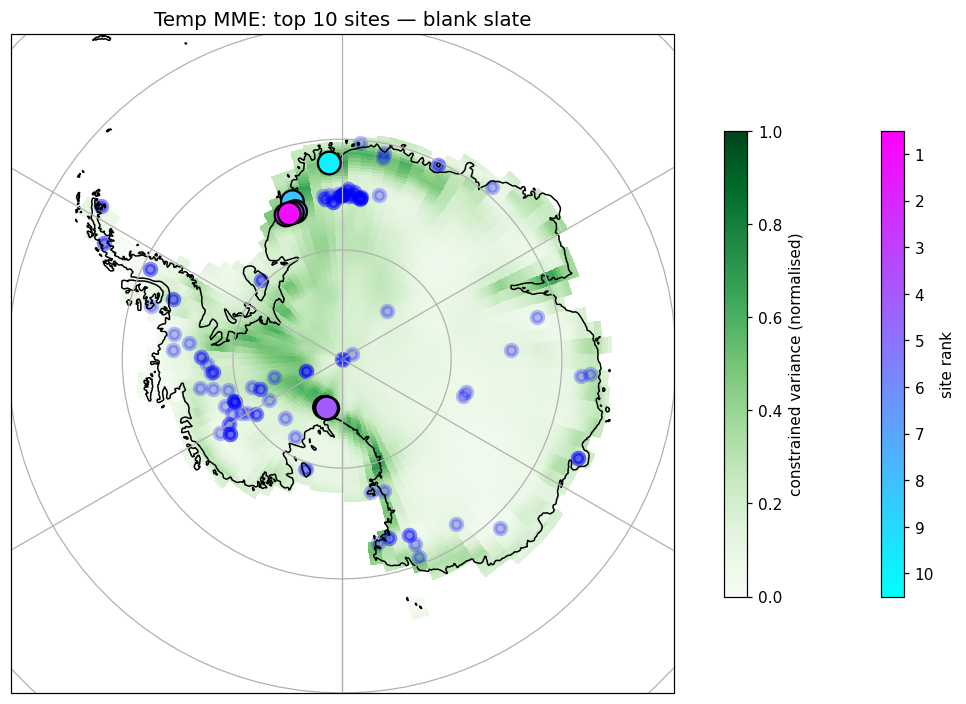

,site,lat,lon,remaining_var,cum_pct
rank,,,,,
1,4446,-75.8639,340.00,0.6093,1.6955
2,4445,-75.8639,338.75,0.5999,3.2256
3,4447,-75.8639,341.25,0.5912,4.6187
4,1598,-85.2880,197.50,0.5831,5.9288
5,1599,-85.2880,198.75,0.5756,7.1472
6,4448,-75.8639,342.50,0.5683,8.3242
7,1597,-85.2880,196.25,0.5613,9.4421
8,4654,-74.9215,342.50,0.5548,10.4886
9,1600,-85.2880,200.00,0.5487,11.4864


In [76]:
N_NEW = 10

os_iter = OptimalSensor(J, Ye[:N_POTENTIAL], R[:N_POTENTIAL])
print(f'Top {N_NEW} sites — blank slate:')
sites_it, var_it = os_iter.run(N_NEW)

def plot_top_sites(field, top_idx, title, top_size=220, cmap_field=plt.cm.Greens):
    """Interpolated field + blue existing proxies + ranked circles (pink=1, cyan=N),
    with separate colorbars for the field and the rank.
    Circles are drawn worst-first so rank 1 ends up on top where they overlap."""
    n = len(top_idx)
    lon_grid = np.linspace(site_lon.min(), site_lon.max(), 100)
    lat_grid = np.linspace(site_lat.min(), site_lat.max(), 100)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    d, _ = cKDTree(np.column_stack((site_lon, site_lat))).query(
        np.column_stack((lon_mesh.ravel(), lat_mesh.ravel())))
    grid = griddata((site_lon, site_lat), field, (lon_mesh, lat_mesh), method='linear')
    grid[d.reshape(lon_mesh.shape) > 1.0] = np.nan

    fig = plt.figure(figsize=(12, 11))
    ax = plt.axes(projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.gridlines()
    pm = ax.pcolormesh(lon_mesh, lat_mesh, grid, zorder=0,
                       transform=ccrs.PlateCarree(), cmap=cmap_field, vmin=0, vmax=1)
    ax.scatter(exist_lon, exist_lat, c='blue', s=50, linewidth=3, alpha=0.25,
               zorder=1, transform=ccrs.PlateCarree())
    ax.coastlines()

    # matplotlib has no per-point zorder within one scatter, so reverse the
    # draw order: rank N is painted first, rank 1 last.
    ranks = np.arange(1, n + 1)
    order = np.arange(n)[::-1]
    sc = ax.scatter(site_lon[top_idx][order], site_lat[top_idx][order],
                    c=ranks[order], s=top_size, linewidth=1.5, edgecolors='black',
                    cmap=plt.cm.cool_r, vmin=0.5, vmax=n + 0.5, zorder=3,
                    transform=ccrs.PlateCarree())

    cb_rank = fig.colorbar(sc, ax=ax, shrink=0.5, pad=0.03, ticks=ranks)
    cb_rank.set_label('site rank')
    cb_rank.ax.invert_yaxis()                    # rank 1 at the top
    cb_field = fig.colorbar(pm, ax=ax, shrink=0.5, pad=0.06)
    cb_field.set_label('constrained variance (normalised)')

    ax.set_title(title, fontsize=13)
    plt.show()
    return fig, ax


plot_top_sites(frac_blank, sites_it,
               f'{VARIABLE} {ENSEMBLE}: top {N_NEW} sites — blank slate')

pd.DataFrame({'rank': np.arange(1, N_NEW+1), 'site': sites_it,
              'lat': site_lat[sites_it], 'lon': site_lon[sites_it],
              'remaining_var': var_it,
              'cum_pct': 100*(1 - var_it/os_iter.J0var)}).set_index('rank').round(4)


Top 10 sites — augmented (after the existing 118):
    1  site  1598 ( -85.29,  197.50)  var 0.474619   cumulative  23.4%
    2  site  1599 ( -85.29,  198.75)  var 0.469532   cumulative  24.3%
    3  site  1597 ( -85.29,  196.25)  var 0.464806   cumulative  25.0%
    4  site  1600 ( -85.29,  200.00)  var 0.460358   cumulative  25.7%
    5  site  3297 ( -79.63,  161.25)  var 0.456186   cumulative  26.4%
    6  site  4447 ( -75.86,  341.25)  var 0.452149   cumulative  27.1%
    7  site  1601 ( -85.29,  201.25)  var 0.448263   cumulative  27.7%
    8  site  3298 ( -79.63,  162.50)  var 0.44454   cumulative  28.3%
    9  site  4448 ( -75.86,  342.50)  var 0.440927   cumulative  28.9%
   10  site  1602 ( -85.29,  202.50)  var 0.437468   cumulative  29.4%


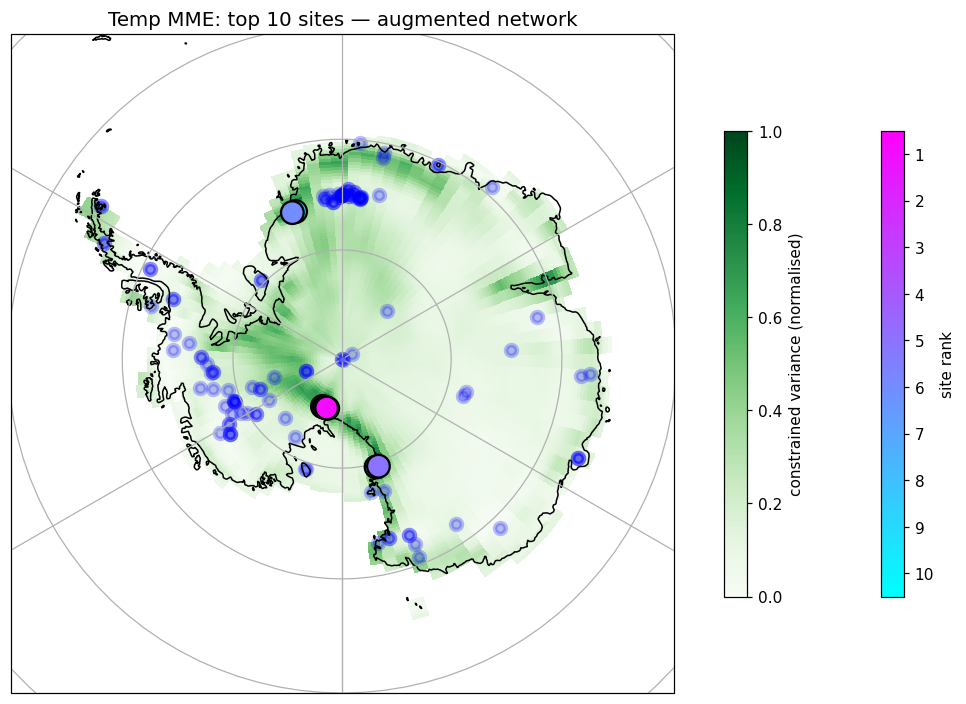


variance after existing 118 : 0.48003 (22.6% of total already constrained)
after 10 more sites      : 0.437468 (29.4% of total)


,site,lat,lon,remaining_var,pct_of_remaining,pct_of_total
rank,,,,,,
1,1598,-85.2880,197.50,0.4746,1.1272,23.4306
2,1599,-85.2880,198.75,0.4695,2.1868,24.2512
3,1597,-85.2880,196.25,0.4648,3.1714,25.0137
4,1600,-85.2880,200.00,0.4604,4.0981,25.7313
5,3297,-79.6335,161.25,0.4562,4.9671,26.4043
6,4447,-75.8639,341.25,0.4521,5.8080,27.0555
7,1601,-85.2880,201.25,0.4483,6.6176,27.6825
8,3298,-79.6335,162.50,0.4445,7.3932,28.2831
9,4448,-75.8639,342.50,0.4409,8.1460,28.8661


In [77]:
N_NEW_AUG = 10

# Fresh object so Cell 7's os_aug isn't mutated by run().
os_aug_iter = OptimalSensor(J, Ye, R)
for idx in range(N_SITES - 1, N_POTENTIAL - 1, -1):    # assimilate the 118 first
    os_aug_iter.assimilate(idx)
v0_aug = os_aug_iter.metric_variance()

print(f'Top {N_NEW_AUG} sites — augmented (after the existing 118):')
sites_aug, var_aug = os_aug_iter.run(N_NEW_AUG)
assert (sites_aug < N_POTENTIAL).all(), 'an existing-proxy index was selected'

plot_top_sites(frac_aug, sites_aug,
               f'{VARIABLE} {ENSEMBLE}: top {N_NEW_AUG} sites — augmented network')

aug_table = pd.DataFrame({
    'rank': np.arange(1, N_NEW_AUG+1), 'site': sites_aug,
    'lat': site_lat[sites_aug], 'lon': site_lon[sites_aug],
    'remaining_var': var_aug,
    'pct_of_remaining': 100*(1 - var_aug/v0_aug),        # vs post-existing baseline
    'pct_of_total':     100*(1 - var_aug/os_aug_iter.J0var),
}).set_index('rank')

print(f'\nvariance after existing 118 : {v0_aug:.6g} '
      f'({100*(1-v0_aug/os_aug_iter.J0var):.1f}% of total already constrained)')
print(f'after {N_NEW_AUG} more sites      : {var_aug[-1]:.6g} '
      f'({aug_table.pct_of_total.iloc[-1]:.1f}% of total)')
aug_table.round(4)
